## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


## **Business Understanding**

### ***The Business Problem***
Your company now sees all the big companies creating original video content and they want to get in on the fun. They have decided to create a new movie studio, but they don’t know anything about creating movies. You are charged with exploring what types of films are currently doing the best at the box office. You must then translate those findings into actionable insights that the head of your company's new movie studio can use to help decide what type of films to create.

### ***Key Stakeholders***
+ Studio Management
     + Studio Manager
     + Operatios Managers
     + Finance Manager (CFO)
+ Producers and studio crew

### ***Key Objectives/Business questions***
1. Which genres deliver the best financial return? (measured by ROI and median profit) 
2. Which genres do best with an international audience 
3. Which studios perform best and do they align with the top genres

### *Key Metrics of Success according to studio KPIs*


---

## **Data Understanding**
+ For this analysis, I will at the bom.movies_gross.csv.gz dataset for analysis using pandas.
+ For SQL, the database to be used is the im.db, specifically the movie_basics and movie_ratings tables

The main objectives in this initial data understanding is to:
+ Find the column names
+ The shape
+ Any missing values and duplicates
+ Understand the data types 
+ etc

In [116]:
# import the needed libraries and modules:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [117]:
# Make a connection to the database for the sqlite
conn = sqlite3.connect('zippedData/im.db/im.db')

In [118]:
cur = conn.cursor()

In [119]:
bommovies_df = pd.read_csv("zippedData/bom.movie_gross.csv.gz")

#### **Data Inspection on: bom.movies_gross.csv.gz**

In [120]:
bommovies_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [121]:
bommovies_df.shape

# From the ouput below, there are 3,387 rows and 5 columns in the dataset of bom.movie_grosss.csv.gz

(3387, 5)

In [122]:
bommovies_df.tail()

,title,studio,domestic_gross,foreign_gross,year
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018
3386,An Actor Prepares,Grav.,1700.0,NaN,2018


In [207]:
print("Dataset Information:")
print(bommovies_df.info())

print("Statistical Assesment:")
bommovies_df.describe().T



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB
None
Statistical Assesment:


,count,mean,std,min,25%,50%,75%,max
domestic_gross,3359.0,2.874585e+07,6.698250e+07,100.0,120000.0,1400000.0,27900000.0,936700000.0
foreign_gross,2037.0,7.487281e+07,1.374106e+08,600.0,3700000.0,18700000.0,74900000.0,960500000.0
year,3387.0,2.013958e+03,2.478141e+00,2010.0,2012.0,2014.0,2016.0,2018.0


In [ ]:
print("Dataset Datatypes:")
bommovies_df.dtypes

Dataset Datatypes:


title              object
studio             object
domestic_gross    float64
foreign_gross     float64
year                int64
dtype: object

In [215]:
# Finding Duplicates and Missing Values
print("Duplicates:")
bommovies_df.duplicated().sum()



Duplicates:


0

**There are no duplicates**

In [217]:
# Finding the Missing Values:
print("NaN")
bommovies_df.isna().sum()

NaN


title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [130]:
# Missing values in %
def missing(bommovies_df,col):
    missing = (bommovies_df[col].isna().sum()/len(bommovies_df))*100
    if missing == 0:
        print(f" we have {missing} % missing from {col}")
    elif missing < 5:
        print(f" we have {missing} % missing from {col} we can go ahead and either drop the rows or fill in the missing values")
    elif missing < 30:
        print(f" we have {missing} % missing from {col} we can go ahead and fill in the missing values")
    else :
        print(f" we have {missing} % missing from {col} we can go ahead and drop the column or consider other alternatives")

In [220]:
missing(bommovies_df,'studio')

 we have 0.14762326542663123 % missing from studio we can go ahead and either drop the rows or fill in the missing values


In [132]:
missing(bommovies_df,'domestic_gross')

 we have 0.8266902863891349 % missing from domestic_gross we can go ahead and either drop the rows or fill in the missing values


In [ ]:
missing(bommovies_df, 'foreign_gross')

 we have 39.85828166519043 % missing from foreign_gross we can go ahead and drop the column or consider other alternatives
None


- studio has missing data of only 5 with a percentage of 0.14. This is insignifanct to warrant dropping the column.
- domestic gross has missing data of 28 with a percentage of 0.83. This is not sufficient enough to have this data dropped.
- foreign gross has missing data. This column has the highest number of NaN the 1350 accounting for the percentage of 39.86. This will not be dropped nevertheless!

**NOTE**
- foreign gross should be float not object 
- year data to be datetime 

In [146]:
# The foreign gross has been converted into the data type of float!
bommovies_df['foreign_gross'] = bommovies_df['foreign_gross'].replace(',','').astype('float')
bommovies_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


### **Movie Data ERD**
![alt text](movie_data_erd.jpeg)


#### **im.db dataset with an a keen interest in the movie_basics and movie_ratings tables**

In [ ]:
queryone = pd.read_sql(""" SELECT name FROM sqlite_master WHERE type = 'table';""",conn)
queryone

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [ ]:
# im.db movie_ratings

ratings = pd.read_sql("""
SELECT * FROM movie_ratings
;
""", conn)

ratings.head()

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


In [ ]:
ratings.tail()

,movie_id,averagerating,numvotes
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5
73855,tt9894098,6.3,128


In [ ]:
ratings.shape

(73856, 3)

In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73856 entries, 0 to 73855
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       73856 non-null  object 
 1   averagerating  73856 non-null  float64
 2   numvotes       73856 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 1.7+ MB


In [ ]:
ratings.describe().T

,count,mean,std,min,25%,50%,75%,max
averagerating,73856.0,6.332729,1.474978,1.0,5.5,6.5,7.4,10.0
numvotes,73856.0,3523.662167,30294.022971,5.0,14.0,49.0,282.0,1841066.0


---

#### **The movie_basics table in the im.db database**

In [ ]:
# im.db movie_basics
basics_querry = pd.read_sql(""" 
SELECT * FROM movie_basics;""",conn)
basics_querry.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [ ]:
basics_querry.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None
146143,tt9916754,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,2013,NaN,Documentary


In [ ]:
basics_querry.shape

(146144, 6)

In [ ]:
basics_querry.describe().T

,count,mean,std,min,25%,50%,75%,max
start_year,146144.0,2014.621798,2.733583,2010.0,2012.0,2015.0,2017.0,2115.0
runtime_minutes,114405.0,86.187247,166.360590,1.0,70.0,87.0,99.0,51420.0


In [ ]:
# From the output, there are no duplicates
basics_querry.duplicated().sum()

0

In [ ]:
basics_querry.isna().sum()

movie_id               0
primary_title          0
original_title        21
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64

In [ ]:
genre = pd.read_sql(""" SELECT genres FROM movie_basics;""",conn)
genre.head()

,genres
0,"Action,Crime,Drama"
1,"Biography,Drama"
2,Drama
3,"Comedy,Drama"
4,"Comedy,Drama,Fantasy"


In [ ]:
genre1 = pd.read_sql(""" SELECT original_title, genres FROM movie_basics;""",conn)
genre1.head()

,original_title,genres
0,Sunghursh,"Action,Crime,Drama"
1,Ashad Ka Ek Din,"Biography,Drama"
2,The Other Side of the Wind,Drama
3,Sabse Bada Sukh,"Comedy,Drama"
4,La Telenovela Errante,"Comedy,Drama,Fantasy"


In [201]:
genre1.shape

(146144, 2)

In [ ]:
# Your code here - remember to use markdown cells for comments as well!

**Possible Qs:**
- does ratings affect box office success 
- which genre performs well financially - will need to feauture engineer a primary genre column 
- Which studios are most successful, and does that align with the top-performing genres? 
- Out of the films that has a foreign relase, which genre was most successfull amongst international viewers

---

### **BUSINESS QUESTION ANALYSIS:**
##### **Which genres do the best with an international audience? Focus on gross revenue.**

---

##### ***Using the tn.movie_budgets.csv.gz over the bom.movies_gross csv.gz to find the which genre does well in the int'l market!***
1. The tn.movie_budget csv dataset is clean, no duplicates and no missing values. This makes it a suitable dataset for finding the which genre beforms well in the international markets based on gross. 
2. Unlike the foreign_gross in the bom.movie_grosss csv dataset, the foreign_gross has missing value of 39% which would jeopardize our analysis.

In [ ]:
tn_df = pd.read_csv("zippedData/tn.movie_budgets.csv.gz")
tn_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [ ]:
print("DATASET INFORMATION")
print(tn_df.info())

print("DATASET DATA TYPES")
print(tn_df.dtypes)
print(tn_df.shape)
# print(tn_df.duplicated())

print("DUPLICATED ROWS")
print(tn_df.duplicated().sum())

print("MISING VALUES")
print(tn_df.isna().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB
None
DATASET DATA TYPES
id                    int64
release_date         object
movie                object
production_budget    object
domestic_gross       object
worldwide_gross      object
dtype: object
(5782, 6)
DUPLICATED ROWS
0
MISING VALUES
id                   0
release_date         0
movie                0
production_budget    0
domestic_gross       0
worldwide_gross      0
dtype: int64


1. **Since the financial figures for production_budget, domestic_gross and worldwide_gross are in objects format, I will convert them to floats formats.**
2. **The release_date is also in object format, this will need to be converted into the time format**

In [ ]:
# Converting the money columns from the object datatype into the float format!
tn_df[['production_budget', 'domestic_gross', 'worldwide_gross']] = tn_df[['production_budget', 'domestic_gross', 'worldwide_gross']].replace(r'[$,]','', regex=True).astype('float')
tn_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,425000000.0,760507625.0,2.776345e+09
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09
2,3,"Jun 7, 2019",Dark Phoenix,350000000.0,42762350.0,1.497624e+08
3,4,"May 1, 2015",Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,317000000.0,620181382.0,1.316722e+09


In [149]:
# Converting the release_date into the date format!
tn_df['release_date'] = pd.to_datetime(tn_df['release_date']).dt.year
tn_df.head(2)

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,1970,Avatar,425000000.0,760507625.0,2.776345e+09
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09


In [148]:
# To check if the money columns have been converted into float.
print(tn_df.dtypes)

id                     int64
release_date           int64
movie                 object
production_budget    float64
domestic_gross       float64
worldwide_gross      float64
dtype: object


##### **Merge the tn.movie_budget csv.gz and the column in the im.db called movie_basics.** 
##### **basics_querry and tn_df**

In [165]:
# Now I merge the datasets using an inner join on the primary title and movie. This will give us a combined dataset with both financial and genre information for each movie.
mixed_df = pd.merge(tn_df, basics_querry,
                    left_on="movie",
                    right_on="primary_title",
                    how="inner")

mixed_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,1,1970,Avatar,425000000.0,760507625.0,2.776345e+09,tt1775309,Avatar,Abatâ,2011,93.0,Horror
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy"
2,3,1970,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,tt6565702,Dark Phoenix,Dark Phoenix,2019,113.0,"Action,Adventure,Sci-Fi"
3,4,1970,Avengers: Age of Ultron,330600000.0,459005868.0,1.403014e+09,tt2395427,Avengers: Age of Ultron,Avengers: Age of Ultron,2015,141.0,"Action,Adventure,Sci-Fi"
4,7,1970,Avengers: Infinity War,300000000.0,678815482.0,2.048134e+09,tt4154756,Avengers: Infinity War,Avengers: Infinity War,2018,149.0,"Action,Adventure,Sci-Fi"


In [174]:
# My main focus is the genres column as well as the worldwide_gross because I am trying to understand the which genre did best with the int'l audience based on gross revenue.
# I will therefore try to split the genres column to create a new row for each genre associated with a movie. This will allow us to analyze the data by genre more easily.
genre_df = mixed_df.copy()
genre_df["genre"] = genre_df["genres"].str.split(",")
genre_df = genre_df.explode("genre")
genre_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,genre
0,1,1970,Avatar,425000000.0,760507625.0,2.776345e+09,tt1775309,Avatar,Abatâ,2011,93.0,Horror,Horror
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy",Action
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy",Adventure
1,2,1970,Pirates of the Caribbean: On Stranger Tides,410600000.0,241063875.0,1.045664e+09,tt1298650,Pirates of the Caribbean: On Stranger Tides,Pirates of the Caribbean: On Stranger Tides,2011,136.0,"Action,Adventure,Fantasy",Fantasy
2,3,1970,Dark Phoenix,350000000.0,42762350.0,1.497624e+08,tt6565702,Dark Phoenix,Dark Phoenix,2019,113.0,"Action,Adventure,Sci-Fi",Action


In [222]:
# Make sure worldwide_gross is numeric first
#genre_df['worldwide_gross'] = pd.to_numeric(genre_df['worldwide_gross'], errors='coerce')

# Total worldwide gross by genre
genre_totals = genre_df.groupby('genre')['worldwide_gross'].sum().sort_values(ascending=False)

# Average worldwide gross by genre (per movie)
genre_avg = genre_df.groupby('genre')['worldwide_gross'].mean().sort_values(ascending=False)

genre_median = genre_df.groupby('genre')['worldwide_gross'].median().sort_values(ascending=False)

print("TOTAL GENRES")
print(genre_totals.head())

print("GENRE AVG")
print(genre_avg.head(10))

TOTAL GENRES
genre
Adventure    1.383342e+11
Action       1.250989e+11
Drama        1.077621e+11
Comedy       8.614621e+10
Sci-Fi       5.099076e+10
Name: worldwide_gross, dtype: float64
GENRE AVG
genre
Animation    2.997924e+08
Adventure    2.823146e+08
Sci-Fi       2.226671e+08
Musical      2.221234e+08
Fantasy      2.158785e+08
Action       1.761956e+08
Family       1.559764e+08
Comedy       1.023114e+08
Thriller     7.630534e+07
History      7.359891e+07
Name: worldwide_gross, dtype: float64


In [199]:
genre_counts = genre_df.groupby('genre')['worldwide_gross'].count().sort_values(ascending=False)

genre_summary = pd.DataFrame({
    'total_gross': genre_totals,
    'avg_gross': genre_avg,
    'movie_count': genre_counts
}).sort_values('avg_gross', ascending=False)

genre_summary

,total_gross,avg_gross,movie_count
Animation,4.436927e+10,2.997924e+08,148
Adventure,1.383342e+11,2.823146e+08,490
Sci-Fi,5.099076e+10,2.226671e+08,229
Musical,7.774320e+09,2.221234e+08,35
Fantasy,4.360745e+10,2.158785e+08,202
Action,1.250989e+11,1.761956e+08,710
Family,3.181919e+10,1.559764e+08,204
Comedy,8.614621e+10,1.023114e+08,842
Thriller,4.532537e+10,7.630534e+07,594
History,7.065495e+09,7.359891e+07,96


In [226]:
# genre_summary['pct_of_total_gross'] = (genre_summary['total_gross'] / genre_summary['total_gross'].sum()) * 100
# genre_summary

In [230]:
genre_summary['pct_of_total_gross'] = genre_summary['pct_of_total_gross'].round(2)
genre_summary

,total_gross,avg_gross,movie_count,pct_of_total_gross
Animation,4.436927e+10,2.997924e+08,148,5.26
Adventure,1.383342e+11,2.823146e+08,490,16.40
Sci-Fi,5.099076e+10,2.226671e+08,229,6.05
Musical,7.774320e+09,2.221234e+08,35,0.92
Fantasy,4.360745e+10,2.158785e+08,202,5.17
Action,1.250989e+11,1.761956e+08,710,14.83
Family,3.181919e+10,1.559764e+08,204,3.77
Comedy,8.614621e+10,1.023114e+08,842,10.22
Thriller,4.532537e+10,7.630534e+07,594,5.37
History,7.065495e+09,7.359891e+07,96,0.84


##### **Why you want both .sum() and .mean(), not just one:**

+ .sum() tells you which genre generated the most total box office money — but this favors genres that simply appear in more movies (like Drama, which shows up constantly as a secondary genre tag).
+ .mean() tells you which genre performs best per movie — a genre with only 5 movies but huge average gross (e.g., a handful of blockbuster sci-fi films) can beat a genre with 500 mediocre movies.

For a "which genre did best" business question, .mean() is usually the more honest answer, but it's worth showing both and being explicit about which one you're using and why.

##### **Visualization**

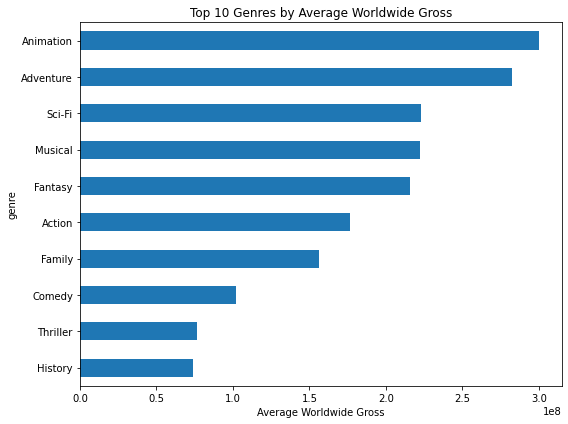

In [193]:
import matplotlib.pyplot as plt

genre_avg.head(10).plot(kind='barh', figsize=(8,6))
plt.xlabel('Average Worldwide Gross')
plt.title('Top 10 Genres by Average Worldwide Gross')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### **FINDINGS AND RECOMMENDATIONS:**

1. ##### **Why USE tn.movie_budgets csv.gz OVER bom.movies_gross csv.gz**
1. The tn.movie_budget csv dataset is clean, no duplicates and no missing values. This makes it a suitable dataset for finding the which genre beforms well in the international markets based on gross. 
2. Unlike the foreign_gross in the bom.movie_grosss csv dataset, the foreign_gross has missing value of 39% which would jeopardize our analysis.

1. ##### **Why you want both .sum() and .mean(), not just one:**

+ .sum() tells you which genre generated the most total box office money — but this favors genres that simply appear in more movies (like Drama, which shows up constantly as a secondary genre tag).
+ .mean() tells you which genre performs best per movie — a genre with only 5 movies but huge average gross (e.g., a handful of blockbuster sci-fi films) can beat a genre with 500 mediocre movies.

For a "which genre did best" business question, .mean() is usually the more honest answer, but it's worth showing both and being explicit about which one you're using and why.


##### **RECOMMENDATIONS**
+ Based on the worldwide gross, the studio should start with making films in the Animation genre.
+ It is also worth noting that movie count number does not translate to higher gross margins. An emphasis should be placed on making quality movies rather making lots of movies which may not be of great quality.
+  The movie making company can go with films in the Adventure and Action genres if they are to consider gross total gross margins only with looking at the average (mean).


##### *BONUS FROM CLAUDE ON THE % ON THE TOTAL GROSS*
A quick heads-up on interpreting this: since a movie can belong to multiple genres (that's the whole reason you exploded the genres column earlier), these percentages will not sum to 100% — each movie's gross gets counted once for every genre it's tagged with. So this tells you "what share of all genre-tagged gross belongs to this genre," not "what share of the actual box office this genre represents" in a strict, non-overlapping sense. Worth mentioning as a caveat if this goes into your write-up.

---
